In [84]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

# 1. Import Libraries

In this step, we import all the Python libraries required for the Telecom Customer Churn Analysis.

### Libraries Used

* **Pandas** – Data loading, cleaning, manipulation, and analysis.
* **NumPy** – Numerical calculations.
* **Matplotlib** – Creating visualizations.
* **Seaborn** – Creating statistical and business-oriented visualizations.
* **Scikit-learn** – Data preprocessing, machine learning, model evaluation, and classification.
* **OS** – Checking whether the CSV file exists.
* **Warnings** – Suppressing unnecessary warning messages.

These libraries provide the foundation for descriptive, diagnostic, predictive, and visualization analysis.

In [85]:
# ============================================================
# 2. SET FILE PATH
# ============================================================

file_path = r"C:\Users\pravi\PycharmProjects\JupyterProject\Telco_Cust_Churn\WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Check whether file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(
        "CSV file not found. Please check the file path."
    )

print("File found successfully!")
print()

File found successfully!



# 2. Set File Path

In this step, we specify the location of the Telecom Customer Churn CSV file.

The program checks whether the file exists before attempting to load it. This prevents file-path errors during execution.

### Objective

* Define the dataset location.
* Verify that the CSV file is available.
* Stop execution with a meaningful error if the file cannot be found.

In [86]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

df = pd.read_csv(file_path)

print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nFirst 5 rows:")
print(df.head())

DATASET LOADED SUCCESSFULLY
Rows: 7043
Columns: 21

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No 

# 3. Load Dataset

The Telecom Customer Churn dataset is loaded into a Pandas DataFrame using `pd.read_csv()`.

A DataFrame allows us to efficiently inspect, clean, transform, analyze, and visualize the customer data.

### Objective

* Load the CSV dataset.
* Determine the number of customers and variables.
* Display the first few records.
* Confirm that the dataset has been loaded successfully.


In [87]:
# ============================================================
# 4. BASIC DATA INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()


DATASET INFORMATION

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Dataset information:
<cl

# 4. Basic Data Information

This step provides an initial understanding of the dataset structure.

We examine:

* Column names
* Number of rows and columns
* Data types
* Dataset information
* Memory usage

Understanding the structure of the data is important before performing data cleaning and analysis.

In [88]:
# ============================================================
# 5. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])


MISSING VALUES
Series([], dtype: int64)


# 5. Check Missing Values

Missing values can affect statistical analysis and machine learning models.

In this step, we identify the number of missing values present in each column.

### Objective

* Detect incomplete records.
* Identify columns requiring data cleaning.
* Decide how missing values should be handled before modeling.


In [89]:
# ============================================================
# 6. CLEAN TOTAL CHARGES
# ============================================================
# TotalCharges is stored as object/string in this dataset.
# Some customers have blank values.
# Convert it to numeric.
# Invalid values become NaN.

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("\nTotalCharges converted to numeric.")


TotalCharges converted to numeric.


# 6. Clean `TotalCharges`

The `TotalCharges` column contains numerical customer billing information, but some values are stored as text.

We convert the column into a numeric data type using `pd.to_numeric()`.

Invalid or blank values are converted into `NaN` so that they can be handled appropriately.

### Objective

Convert `TotalCharges` into a proper numerical variable for statistical analysis and machine learning.


In [90]:
# ============================================================
# 7. HANDLE MISSING TOTALCHARGES
# ============================================================

print("\nMissing TotalCharges after conversion:")
print(df["TotalCharges"].isnull().sum())

# Fill missing TotalCharges with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)


Missing TotalCharges after conversion:
11


# 7. Handle Missing `TotalCharges`

After converting `TotalCharges` into numeric format, we check whether any missing values remain.

Missing values are replaced with `0` so that the dataset can be processed by the machine learning pipeline.

### Objective

Ensure that the numerical `TotalCharges` feature does not contain missing values before further analysis.


In [91]:
# ============================================================
# 8. CHECK DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE RECORDS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")


DUPLICATE RECORDS
Number of duplicate rows: 0


# 8. Check Duplicate Records

Duplicate records can distort descriptive statistics and may negatively affect machine learning models.

In this step, we identify duplicate rows in the dataset.

If duplicates exist, they are removed so that every customer record is represented only once.

### Objective

Maintain data quality and avoid duplicate customer observations.


In [92]:
# ============================================================
# 9. DESCRIPTIVE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("DESCRIPTIVE ANALYSIS")
print("=" * 70)
# ------------------------------------------------------------
# 9.1 Numerical Summary
# ------------------------------------------------------------

print("\nNumerical Summary:")
print(df.describe())


DESCRIPTIVE ANALYSIS

Numerical Summary:
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7043.000000
mean        0.162147    32.371149       64.761692   2279.734304
std         0.368612    24.559481       30.090047   2266.794470
min         0.000000     0.000000       18.250000      0.000000
25%         0.000000     9.000000       35.500000    398.550000
50%         0.000000    29.000000       70.350000   1394.550000
75%         0.000000    55.000000       89.850000   3786.600000
max         1.000000    72.000000      118.750000   8684.800000


In [93]:
# ------------------------------------------------------------
# 9.2 Churn Distribution
# ------------------------------------------------------------

print("\nCustomer Churn Distribution:")
print(df["Churn"].value_counts())

print("\nCustomer Churn Percentage:")
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(churn_percentage)


Customer Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Customer Churn Percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [94]:
# ------------------------------------------------------------
# 9.3 Customer Demographics
# ------------------------------------------------------------

print("\nGender Distribution:")
print(df["gender"].value_counts())

print("\nSenior Citizen Distribution:")
print(df["SeniorCitizen"].value_counts())

print("\nPartner Distribution:")
print(df["Partner"].value_counts())

print("\nDependents Distribution:")
print(df["Dependents"].value_counts())


Gender Distribution:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Senior Citizen Distribution:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

Partner Distribution:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents Distribution:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64


In [95]:
# ------------------------------------------------------------
# 9.4 Service Information
# ------------------------------------------------------------

print("\nInternet Service Distribution:")
print(df["InternetService"].value_counts())

print("\nContract Distribution:")
print(df["Contract"].value_counts())

print("\nPayment Method Distribution:")
print(df["PaymentMethod"].value_counts())


Internet Service Distribution:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Contract Distribution:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Payment Method Distribution:
PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [96]:
# ------------------------------------------------------------
# 9.5 Numerical Business Metrics
# ------------------------------------------------------------

print("\nAverage Monthly Charges:")
print(round(df["MonthlyCharges"].mean(), 2))

print("\nAverage Total Charges:")
print(round(df["TotalCharges"].mean(), 2))

print("\nAverage Tenure:")
print(round(df["tenure"].mean(), 2))


Average Monthly Charges:
64.76

Average Total Charges:
2279.73

Average Tenure:
32.37


# 9. Descriptive Analysis

## What Happened?

Descriptive analysis summarizes the existing customer data and helps us understand the overall characteristics of the telecom customer base.

We examine:

* Numerical statistics
* Customer churn distribution
* Customer demographics
* Service information
* Contract types
* Payment methods
* Customer tenure
* Monthly charges
* Total charges

### Business Objective

Understand the current customer population before investigating the reasons behind customer churn.

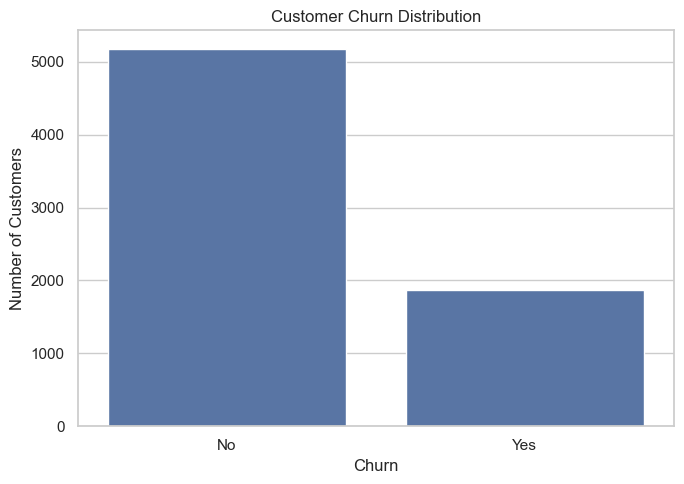

In [97]:
# ============================================================
# 10. DESCRIPTIVE VISUALIZATIONS
# ============================================================

sns.set_theme(style="whitegrid")


# ------------------------------------------------------------
# 10.1 Churn Count
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

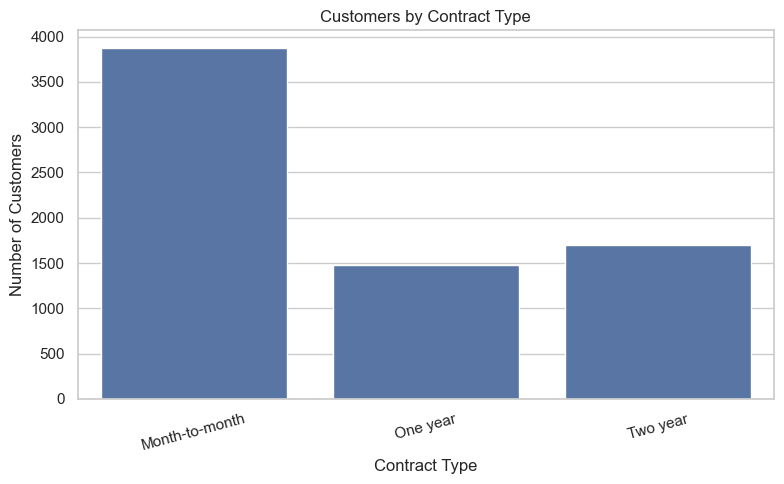

In [98]:
# ------------------------------------------------------------
# 10.2 Contract Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract"
)

plt.title("Customers by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

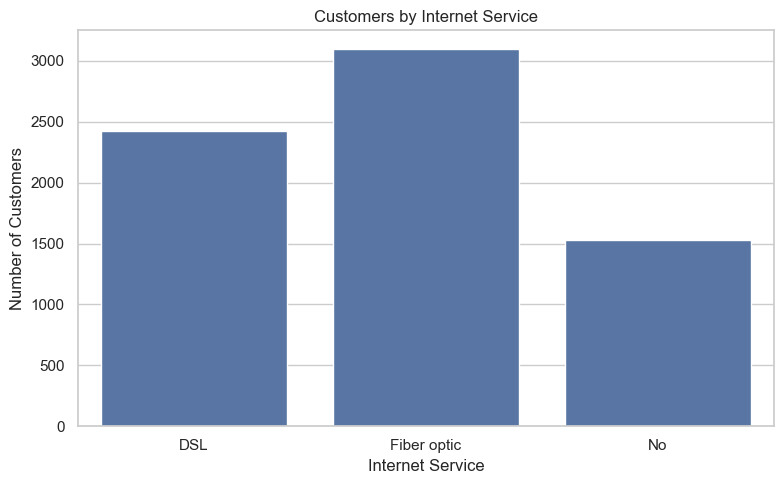

In [99]:
# ------------------------------------------------------------
# 10.3 Internet Service Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService"
)

plt.title("Customers by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

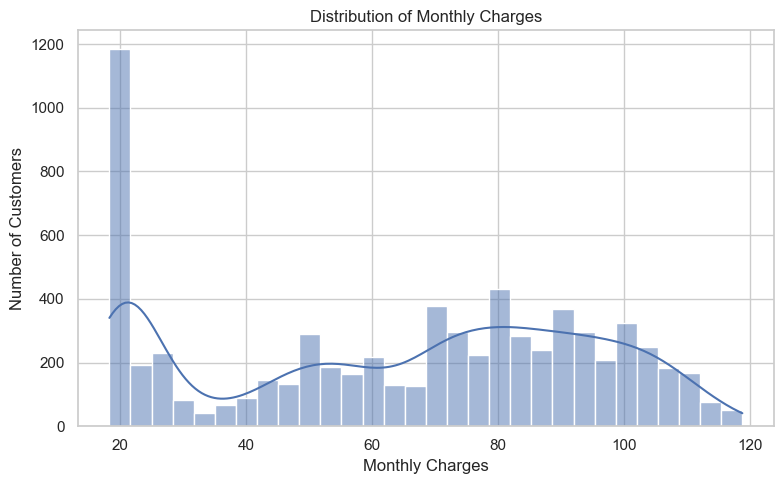

In [100]:
# ------------------------------------------------------------
# 10.4 Monthly Charges Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

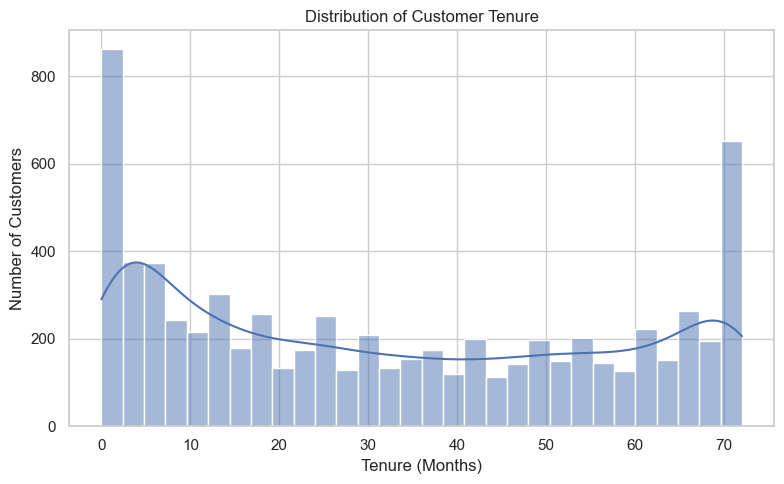

In [101]:
# ------------------------------------------------------------
# 10.5 Tenure Distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# 10. Descriptive Visualizations

Visualization makes it easier to understand the distribution and characteristics of the customer base.

The following visualizations are created:

1. Customer Churn Distribution
2. Customers by Contract Type
3. Customers by Internet Service
4. Monthly Charges Distribution
5. Customer Tenure Distribution

These graphs provide a visual overview of the telecom company's customers.

In [102]:
# ============================================================
# 11. DIAGNOSTIC ANALYSIS
# ============================================================
# Question:
# WHY are customers churning?
# ============================================================

print("\n" + "=" * 70)
print("DIAGNOSTIC ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# 11.1 Churn by Contract
# ------------------------------------------------------------

contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Contract:")
print(contract_churn.round(2))


DIAGNOSTIC ANALYSIS

Churn Percentage by Contract:
Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


In [103]:
# ------------------------------------------------------------
# 11.2 Churn by Internet Service
# ------------------------------------------------------------

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Internet Service:")
print(internet_churn.round(2))


Churn Percentage by Internet Service:
Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


In [104]:
# ------------------------------------------------------------
# 11.3 Churn by Payment Method
# ------------------------------------------------------------

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Payment Method:")
print(payment_churn.round(2))


Churn Percentage by Payment Method:
Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


In [105]:
# ------------------------------------------------------------
# 11.4 Churn by Senior Citizen
# ------------------------------------------------------------

senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Senior Citizen:")
print(senior_churn.round(2))


Churn Percentage by Senior Citizen:
Churn             No    Yes
SeniorCitizen              
0              76.39  23.61
1              58.32  41.68


In [106]:
# ------------------------------------------------------------
# 11.5 Churn by Partner
# ------------------------------------------------------------

partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Partner:")
print(partner_churn.round(2))


Churn Percentage by Partner:
Churn       No    Yes
Partner              
No       67.04  32.96
Yes      80.34  19.66


In [107]:
# ------------------------------------------------------------
# 11.6 Churn by Dependents
# ------------------------------------------------------------

dependent_churn = pd.crosstab(
    df["Dependents"],
    df["Churn"],
    normalize="index"
) * 100

print("\nChurn Percentage by Dependents:")
print(dependent_churn.round(2))


Churn Percentage by Dependents:
Churn          No    Yes
Dependents              
No          68.72  31.28
Yes         84.55  15.45


# 11. Diagnostic Analysis

## Why Are Customers Churning?

Diagnostic analysis investigates relationships between customer churn and important customer characteristics.

We compare churn rates across:

* Contract types
* Internet service types
* Payment methods
* Senior citizen status
* Partner status
* Dependent status

### Business Objective

Identify customer segments and characteristics that are associated with higher churn so that the company can design targeted retention strategies.


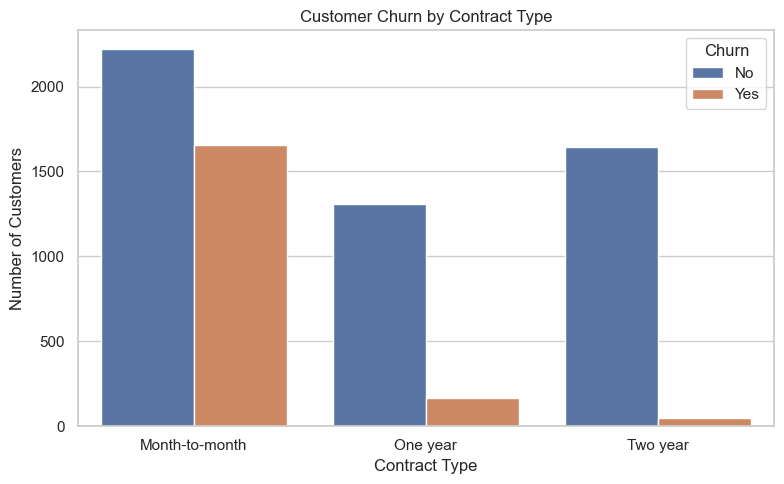

In [108]:
# ============================================================
# 12. DIAGNOSTIC VISUALIZATIONS
# ============================================================


# ------------------------------------------------------------
# 12.1 Contract vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

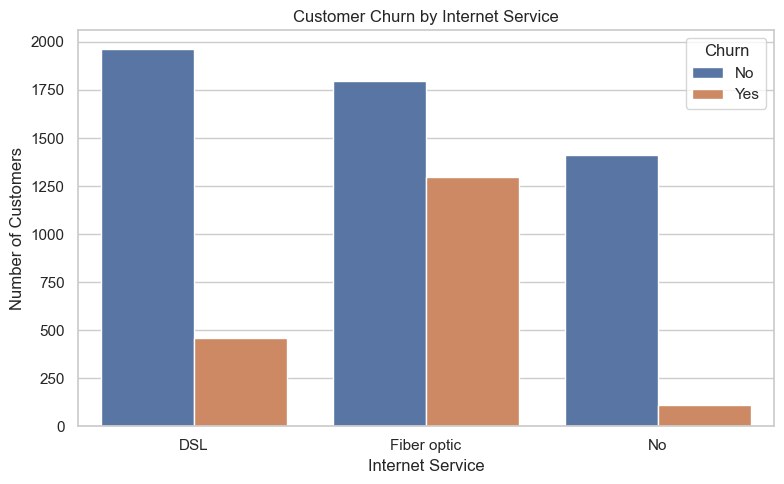

In [109]:
# ------------------------------------------------------------
# 12.2 Internet Service vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

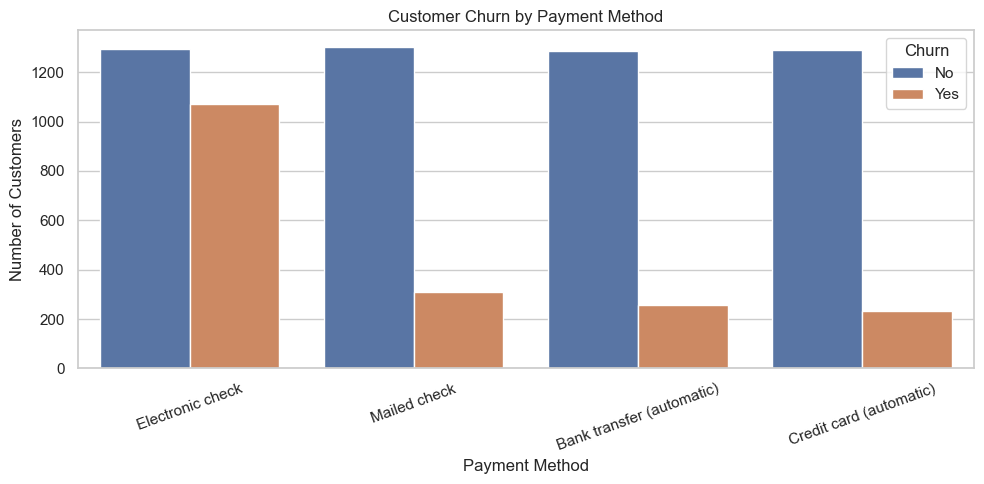

In [110]:
# ------------------------------------------------------------
# 12.3 Payment Method vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

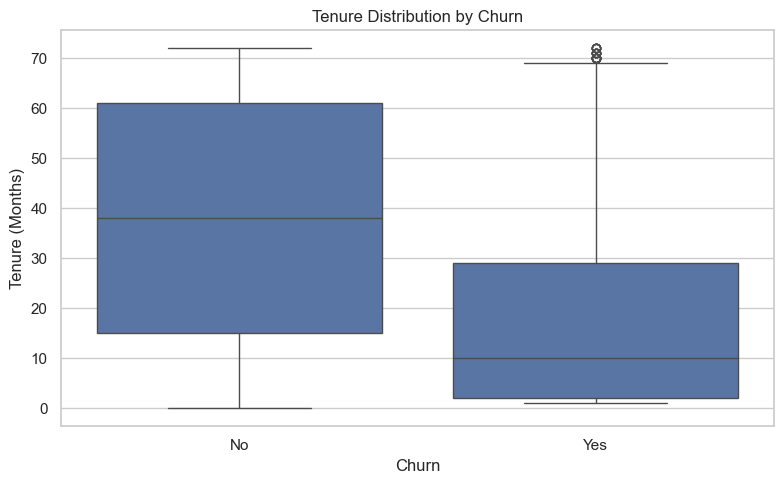

In [111]:
# ------------------------------------------------------------
# 12.4 Tenure vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.tight_layout()
plt.show()

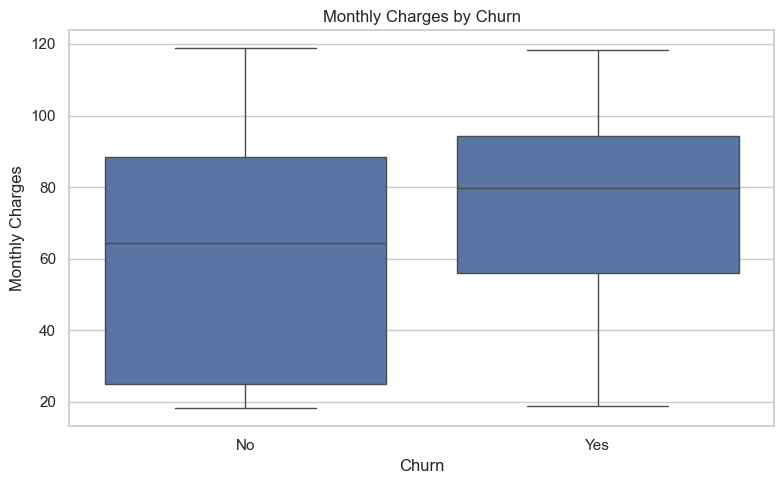

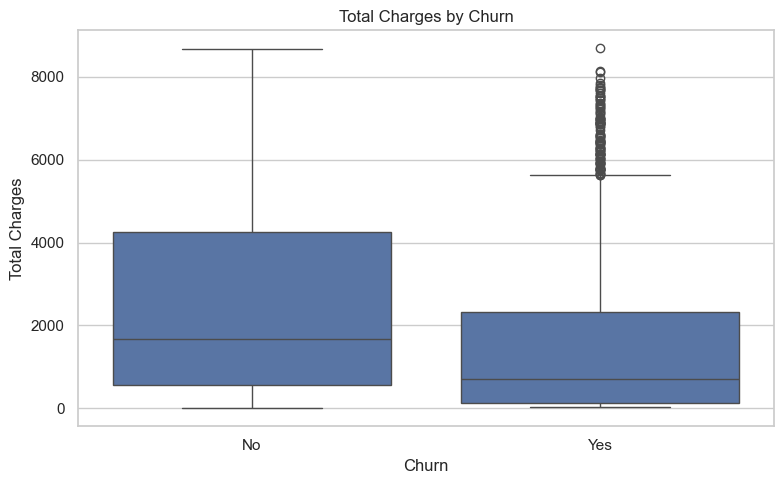

In [112]:
# ------------------------------------------------------------
# 12.5 Monthly Charges vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12.6 Total Charges vs Churn
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")

plt.tight_layout()
plt.show()

# 12. Diagnostic Visualizations

The diagnostic analysis is supported with visualizations to identify patterns in customer churn.

The following relationships are visualized:

* Contract Type vs Churn
* Internet Service vs Churn
* Payment Method vs Churn
* Tenure vs Churn
* Monthly Charges vs Churn
* Total Charges vs Churn

These visualizations help identify potential factors associated with customer cancellation.


In [113]:
# ============================================================
# 13. CORRELATION ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

# Convert Churn to numeric temporarily
df["Churn_numeric"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

numeric_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "Churn_numeric"
]

correlation_matrix = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(2))


CORRELATION ANALYSIS

Correlation Matrix:
                SeniorCitizen  tenure  MonthlyCharges  TotalCharges  \
SeniorCitizen            1.00    0.02            0.22          0.10   
tenure                   0.02    1.00            0.25          0.83   
MonthlyCharges           0.22    0.25            1.00          0.65   
TotalCharges             0.10    0.83            0.65          1.00   
Churn_numeric            0.15   -0.35            0.19         -0.20   

                Churn_numeric  
SeniorCitizen            0.15  
tenure                  -0.35  
MonthlyCharges           0.19  
TotalCharges            -0.20  
Churn_numeric            1.00  


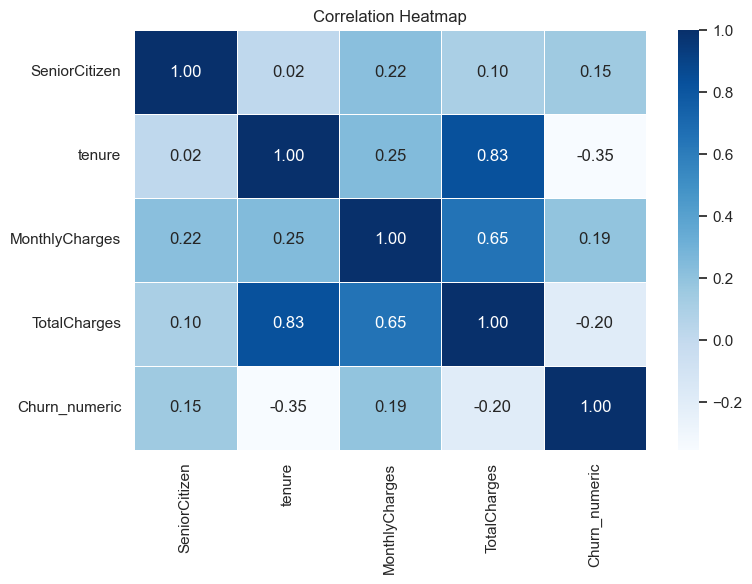

In [114]:
# ------------------------------------------------------------
# Correlation Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()


# Remove temporary column
df.drop("Churn_numeric", axis=1, inplace=True)

# 13. Correlation Analysis

Correlation analysis measures the relationship between numerical variables.

The analysis includes:

* Senior Citizen status
* Customer tenure
* Monthly charges
* Total charges
* Churn

The correlation matrix helps identify whether numerical variables have positive or negative relationships with customer churn.

A heatmap is also used to make these relationships easier to interpret visually.


In [115]:
# ============================================================
# 14. PREPARE DATA FOR MACHINE LEARNING
# ============================================================

print("\n" + "=" * 70)
print("PREDICTIVE ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# Target Variable
# ------------------------------------------------------------

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})


# ------------------------------------------------------------
# Remove Customer ID
# ------------------------------------------------------------

# customerID is only an identifier.
# It should not be used for prediction.

X = df.drop(
    columns=["customerID", "Churn"]
)

y = df["Churn"]


PREDICTIVE ANALYSIS


# 14. Prepare Data for Machine Learning

## Predictive Analysis

The objective of predictive analysis is to build a classification model that can predict whether a customer is likely to churn.

The target variable is:

* **0 → No Churn**
* **1 → Churn**

The `customerID` column is removed because it is an identifier and does not provide meaningful predictive information.

The remaining customer attributes are used as model features.


In [116]:
# ============================================================
# 15. IDENTIFY NUMERICAL & CATEGORICAL FEATURES
# ============================================================

numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]


# 15. Identify Numerical and Categorical Features

Machine learning models require appropriate preprocessing of different types of variables.

### Numerical Features

* SeniorCitizen
* tenure
* MonthlyCharges
* TotalCharges

### Categorical Features

* gender
* Partner
* Dependents
* PhoneService
* MultipleLines
* InternetService
* OnlineSecurity
* OnlineBackup
* DeviceProtection
* TechSupport
* StreamingTV
* StreamingMovies
* Contract
* PaperlessBilling
* PaymentMethod

The numerical and categorical variables will be processed differently before model training.


In [117]:
# ============================================================
# 16. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])


Training records: 5634
Testing records: 1409


# 16. Train-Test Split

The dataset is divided into two subsets:

* **Training data – 80%**
* **Testing data – 20%**

The training dataset is used to teach the machine learning model.

The testing dataset is used to evaluate how well the trained model performs on previously unseen customers.

`stratify=y` is used to maintain a similar churn distribution in both datasets.


In [118]:
# ============================================================
# 17. PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

# 17. Preprocessing Pipeline

A preprocessing pipeline is created to prepare the numerical and categorical features.

### Numerical Variables

Numerical features are standardized using `StandardScaler`.

This places numerical variables on a comparable scale.

### Categorical Variables

Categorical features are converted into numerical representation using `OneHotEncoder`.

`handle_unknown="ignore"` ensures that the model can handle categories appearing in the test data that were not present during training.

This preprocessing is combined into a single `ColumnTransformer`.


In [119]:
# ============================================================
# 18. LOGISTIC REGRESSION MODEL
# ============================================================
# Logistic Regression is appropriate because:
# - This is a binary classification problem.
# - Target = Churn / No Churn.
# - It provides probabilities.
# - It is relatively easy to interpret.

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# 18. Logistic Regression Model

Logistic Regression is used as the predictive classification algorithm.

This problem is a **binary classification problem** because the target has two possible outcomes:

* Customer does not churn
* Customer churns

Logistic Regression is a suitable baseline model because it is:

* Simple
* Fast
* Interpretable
* Suitable for binary classification
* Capable of producing churn probabilities

The model predicts the probability that a customer will churn.


In [120]:
# ============================================================
# 19. CREATE MACHINE LEARNING PIPELINE
# ============================================================

pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            model
        )
    ]
)

# 19. Create Machine Learning Pipeline

The preprocessing steps and Logistic Regression model are combined into a single Scikit-learn pipeline.

### Pipeline Flow

**Raw Customer Data**

↓

**Numerical Scaling + Categorical Encoding**

↓

**Logistic Regression**

↓

**Churn Prediction**

Using a pipeline ensures that the same preprocessing operations are consistently applied during both training and prediction.


In [121]:
# ============================================================
# 20. TRAIN MODEL
# ============================================================

print("\nTraining Logistic Regression model...")

pipeline.fit(
    X_train,
    y_train
)

print("Model training completed.")


Training Logistic Regression model...
Model training completed.


# 20. Train the Machine Learning Model

The Logistic Regression model is trained using the training dataset.

During training, the model learns relationships between customer characteristics and the target variable, customer churn.

### Objective

Learn patterns from historical customer data that can be used to predict churn for new or unseen customers.


In [122]:
# ============================================================
# 21. MAKE PREDICTIONS
# ============================================================

y_pred = pipeline.predict(X_test)

y_probability = pipeline.predict_proba(
    X_test
)[:, 1]

# 21. Make Predictions

The trained model is used to make predictions on the testing dataset.

Two types of predictions are generated:

### 1. Churn Prediction

The model predicts:

* `0` → No Churn
* `1` → Churn

### 2. Churn Probability

The model also calculates the probability that each customer will churn.

This probability is useful for identifying customers who may require immediate retention attention.


In [123]:
# ============================================================
# 22. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)
print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


MODEL PERFORMANCE
Accuracy  : 0.8055
Precision : 0.6572
Recall    : 0.5588
F1 Score  : 0.6040
ROC-AUC   : 0.8421


# 22. Model Evaluation

The predictive model is evaluated using several classification metrics.

### Accuracy

Measures the overall percentage of correctly classified customers.

### Precision

Measures how many customers predicted as churners actually churned.

### Recall

Measures how many actual churners were correctly identified.

### F1 Score

Provides a balance between precision and recall.

### ROC-AUC

Measures the model's ability to distinguish between customers who churn and customers who do not churn.

For a churn prediction business problem, **Recall is particularly important** because missing a customer who is actually going to churn can result in a lost customer.


In [124]:
# ============================================================
# 23. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



# 23. Classification Report

The classification report provides detailed performance metrics for both classes:

* No Churn
* Churn

The report includes:

* Precision
* Recall
* F1-score
* Support

This provides a more detailed understanding of model performance than accuracy alone.



Confusion Matrix:
[[926 109]
 [165 209]]


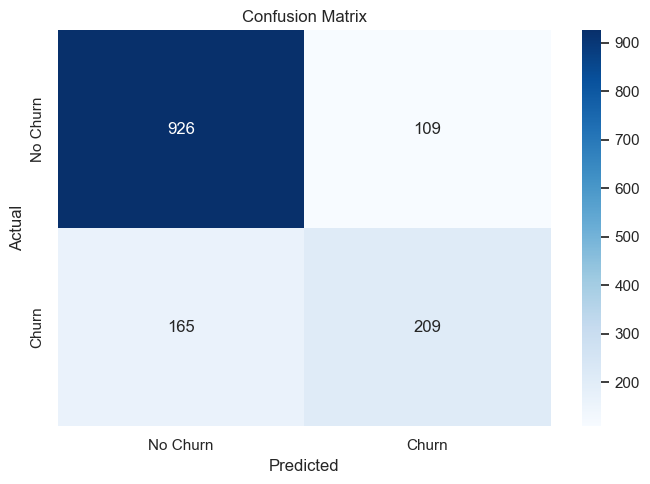

In [125]:
# ============================================================
# 24. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ------------------------------------------------------------
# Confusion Matrix Visualization
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

# 24. Confusion Matrix

A confusion matrix shows how the model's predictions compare with the actual customer outcomes.

It contains four important categories:

* **True Negative (TN)** – Correctly predicted No Churn
* **True Positive (TP)** – Correctly predicted Churn
* **False Positive (FP)** – Predicted Churn but customer did not churn
* **False Negative (FN)** – Predicted No Churn but customer actually churned

### Business Importance

False negatives are particularly important because they represent customers who are likely to churn but were not identified by the model.


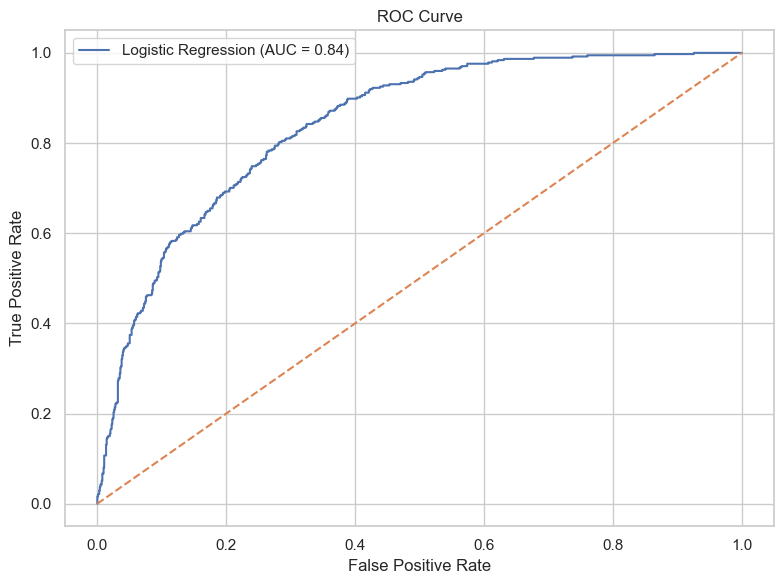

In [126]:
# ============================================================
# 25. ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.tight_layout()
plt.show()

# 25. ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates the classification model across different probability thresholds.

The curve compares:

* True Positive Rate
* False Positive Rate

The **Area Under the Curve (AUC)** summarizes the model's ability to distinguish between churn and non-churn customers.

A higher ROC-AUC generally indicates better discrimination between the two customer groups.


In [127]:
# ============================================================
# 26. PREDICT CHURN PROBABILITY FOR ALL CUSTOMERS
# ============================================================

df_prediction = df.copy()

# Convert target back to Yes/No for reporting
df_prediction["Actual_Churn"] = df_prediction["Churn"].map({
    0: "No",
    1: "Yes"
})


# Predict probability for all customers
all_features = df.drop(
    columns=["customerID", "Churn"]
)

df_prediction["Churn_Probability"] = (
    pipeline.predict_proba(all_features)[:, 1]
)


# Convert probability into percentage
df_prediction["Churn_Probability_%"] = (
    df_prediction["Churn_Probability"] * 100
).round(2)

# 26. Predict Churn Probability for All Customers

After evaluating the model, we use the trained model to calculate the churn probability for every customer in the dataset.

This allows the telecom company to move from simply predicting churn to **prioritizing customers according to their risk level**.

Each customer receives a probability between 0 and 1, which is also converted into a percentage.


In [128]:
# ============================================================
# 27. CREATE CHURN RISK CATEGORY
# ============================================================

def classify_risk(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"


df_prediction["Risk_Category"] = (
    df_prediction["Churn_Probability"]
    .apply(classify_risk)
)

# 27. Create Churn Risk Categories

To make the predictions easier for business teams to understand, customers are grouped into three risk categories.

### Risk Categories

| Churn Probability | Risk Category |
| ----------------- | ------------- |
| Less than 40%     | Low Risk      |
| 40%–69.99%        | Medium Risk   |
| 70% or higher     | High Risk     |

These thresholds are used as practical business segmentation rules for this case study.

Customers in the **High Risk** category should receive the highest retention priority.


In [129]:
# ============================================================
# 28. CUSTOMER CHURN RISK SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CUSTOMER CHURN RISK SUMMARY")
print("=" * 70)

risk_summary = (
    df_prediction["Risk_Category"]
    .value_counts()
)

print(risk_summary)


CUSTOMER CHURN RISK SUMMARY
Risk_Category
Low Risk       4944
Medium Risk    1603
High Risk       496
Name: count, dtype: int64


# 28. Customer Churn Risk Summary

The number of customers in each churn-risk category is calculated.

The summary shows how many customers are classified as:

* Low Risk
* Medium Risk
* High Risk

### Business Objective

Understand the size of each customer risk segment and estimate how many customers may require retention intervention.


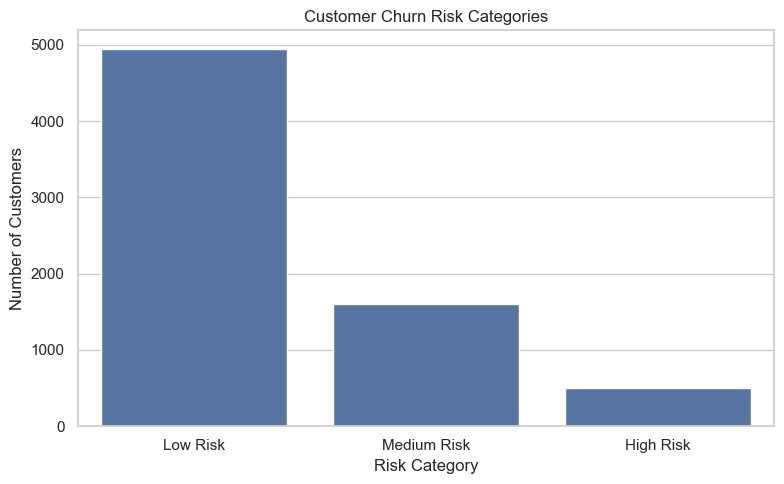

In [130]:
# ============================================================
# 29. RISK CATEGORY VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_prediction,
    x="Risk_Category",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

plt.title("Customer Churn Risk Categories")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# 29. Risk Category Visualization

A bar chart is created to visualize the number of customers in each churn-risk category.

The visualization makes it easier for business stakeholders to understand the distribution of:

* Low-risk customers
* Medium-risk customers
* High-risk customers

This can help management estimate the potential size of the customer retention opportunity.


In [131]:
# ============================================================
# 30. TOP HIGH-RISK CUSTOMERS
# ============================================================

high_risk_customers = (
    df_prediction[
        df_prediction["Risk_Category"] == "High Risk"
    ]
    .sort_values(
        by="Churn_Probability",
        ascending=False
    )
)


print("\n" + "=" * 70)
print("TOP HIGH-RISK CUSTOMERS")
print("=" * 70)

columns_to_display = [
    "customerID",
    "tenure",
    "Contract",
    "InternetService",
    "MonthlyCharges",
    "TotalCharges",
    "PaymentMethod",
    "Actual_Churn",
    "Churn_Probability_%",
    "Risk_Category"
]

print(
    high_risk_customers[
        columns_to_display
    ].head(20)
)


TOP HIGH-RISK CUSTOMERS
      customerID  tenure        Contract InternetService  MonthlyCharges  \
1976  9497-QCMMS       1  Month-to-month     Fiber optic           93.55   
4800  9300-AGZNL       1  Month-to-month     Fiber optic           94.00   
3380  5178-LMXOP       1  Month-to-month     Fiber optic           95.10   
3749  4424-TKOPW       2  Month-to-month     Fiber optic           93.85   
6368  2720-WGKHP       2  Month-to-month     Fiber optic           94.00   
5989  5567-WSELE       3  Month-to-month     Fiber optic           94.60   
1410  7024-OHCCK       2  Month-to-month     Fiber optic           93.85   
3159  5150-ITWWB       3  Month-to-month     Fiber optic           94.85   
2208  7216-EWTRS       1  Month-to-month     Fiber optic          100.80   
997   1374-DMZUI       4  Month-to-month     Fiber optic           94.30   
301   8098-LLAZX       4  Month-to-month     Fiber optic           95.45   
3209  8149-RSOUN       1  Month-to-month     Fiber optic       

# 30. Identify Top High-Risk Customers

The customers with the highest predicted churn probabilities are identified and sorted from highest to lowest risk.

Important customer information is displayed, including:

* Customer ID
* Tenure
* Contract type
* Internet service
* Monthly charges
* Total charges
* Payment method
* Actual churn status
* Churn probability
* Risk category

### Business Objective

Create a prioritized list of customers who may need immediate retention action.


In [136]:
# ============================================================
# 31. EXPORT PREDICTIONS
# ============================================================

output_file = "telecom_customer_churn_predictions.csv"

df_prediction[
    columns_to_display
].to_csv(
    output_file,
    index=False
)

print("\nPrediction file created:")
print(output_file)


Prediction file created:
telecom_customer_churn_predictions.csv


# 31. Export Customer Churn Predictions

The customer-level churn predictions are exported to a CSV file.

The output file contains the customer's:

* ID
* Customer characteristics
* Actual churn status
* Predicted churn probability
* Risk category

### Business Use

The exported file can be provided to the customer retention or marketing team so that high-risk customers can be targeted with appropriate retention campaigns.


In [133]:
# ============================================================
# 32. BUSINESS INSIGHTS
# ============================================================

print("\n" + "=" * 70)
print("BUSINESS INSIGHTS")
print("=" * 70)

print("""
1. Customer churn is a major business risk because losing an
   existing customer creates additional acquisition costs.

2. Contract type is an important churn indicator. Customers
   on shorter contracts generally require greater retention
   attention.

3. Customer tenure is useful for identifying customers who
   may be at higher risk, especially newer customers.

4. Monthly charges can be associated with churn behavior.
   Customers with higher monthly charges may require targeted
   retention offers.

5. Payment method can also reveal differences in churn behavior.

6. Internet service type can help identify customer segments
   that require additional retention strategies.

7. The predictive model assigns each customer a probability
   of churn.

8. High-risk customers can be prioritized for retention campaigns.

9. Instead of giving the same offer to every customer, the
   telecom company can target customers based on their
   predicted churn probability.

10. Retaining high-risk existing customers can potentially
    reduce customer acquisition costs.
""")


BUSINESS INSIGHTS

1. Customer churn is a major business risk because losing an
   existing customer creates additional acquisition costs.

2. Contract type is an important churn indicator. Customers
   on shorter contracts generally require greater retention
   attention.

3. Customer tenure is useful for identifying customers who
   may be at higher risk, especially newer customers.

4. Monthly charges can be associated with churn behavior.
   Customers with higher monthly charges may require targeted
   retention offers.

5. Payment method can also reveal differences in churn behavior.

6. Internet service type can help identify customer segments
   that require additional retention strategies.

7. The predictive model assigns each customer a probability
   of churn.

8. High-risk customers can be prioritized for retention campaigns.

9. Instead of giving the same offer to every customer, the
   telecom company can target customers based on their
   predicted churn probability.

10

# 32. Business Insights

The analysis provides several potential business insights.

### Key Findings to Investigate

1. **Contract type** can be an important churn indicator. Customers on shorter-term contracts may require greater retention attention.

2. **Customer tenure** can help identify customers who are relatively new and may be more vulnerable to churn.

3. **Monthly charges** may be associated with churn behavior and can help identify customer segments requiring targeted offers.

4. **Internet service type** can reveal differences in churn behavior across service segments.

5. **Payment method** may be associated with different customer churn patterns.

6. **Customer risk scores** allow the company to prioritize retention efforts instead of treating every customer equally.

### Business Recommendation

The telecom company should use the churn model as a customer-retention tool. High-risk customers can be identified early and targeted with appropriate interventions such as service support, personalized offers, contract incentives, or loyalty programs.

The ultimate objective is to **reduce customer churn and improve customer retention**, thereby reducing the cost of acquiring replacement customers.


In [134]:
# ============================================================
# 33. FINAL MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)

print(f"""
Dataset Size:
    {df.shape[0]} customers
    {df.shape[1]} variables

Model:
    Logistic Regression

Accuracy:
    {accuracy:.2%}

Precision:
    {precision:.2%}

Recall:
    {recall:.2%}

F1 Score:
    {f1:.2%}

ROC-AUC:
    {roc_auc:.2%}

High-Risk Customers:
    {risk_summary.get("High Risk", 0)}

Medium-Risk Customers:
    {risk_summary.get("Medium Risk", 0)}

Low-Risk Customers:
    {risk_summary.get("Low Risk", 0)}

Business Objective:
    Identify customers with a high probability of churn
    so that the company can take preventive retention action.
""")

print("=" * 70)
print("TELECOM CUSTOMER CHURN ANALYSIS COMPLETED")
print("=" * 70)


FINAL SUMMARY

Dataset Size:
    7043 customers
    21 variables

Model:
    Logistic Regression

Accuracy:
    80.55%

Precision:
    65.72%

Recall:
    55.88%

F1 Score:
    60.40%

ROC-AUC:
    84.21%

High-Risk Customers:
    496

Medium-Risk Customers:
    1603

Low-Risk Customers:
    4944

Business Objective:
    Identify customers with a high probability of churn
    so that the company can take preventive retention action.

TELECOM CUSTOMER CHURN ANALYSIS COMPLETED


# 33. Final Summary

## Telecom Customer Churn Prediction — Final Results

This case study applies descriptive, diagnostic, and predictive analytics to the Telecom Customer Churn dataset.

### Analysis Framework

**Descriptive Analysis**

> What is happening with the customer base?

We examined customer demographics, services, contracts, charges, tenure, and overall churn distribution.

**Diagnostic Analysis**

> Why are customers churning?

We investigated the relationship between churn and factors such as contract type, internet service, payment method, tenure, and customer charges.

**Predictive Analysis**

> Which customers are likely to churn?

A Logistic Regression classification model was developed to predict customer churn and calculate an individual churn probability for each customer.

### Model Evaluation

The model is evaluated using:

* Accuracy
* Precision
* Recall
* F1 Score
* ROC-AUC
* Confusion Matrix
* ROC Curve

### Customer Risk Segmentation

Customers are classified into:

* **Low Risk**
* **Medium Risk**
* **High Risk**

This allows the business to prioritize customers who have a greater probability of cancelling their subscription.

### Final Business Objective

The purpose of this analysis is not only to predict churn, but to enable **proactive customer retention**.

By identifying customers who are likely to churn, the telecom company can intervene earlier, improve customer retention, reduce customer acquisition costs, and potentially increase customer lifetime value.

## Conclusion

**Predictive analytics transforms customer churn data into actionable retention opportunities.**
